In [1]:
import torch 
import torch.nn as nn
from torch.optim.lr_scheduler import MultiStepLR

import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import sys
from itertools import chain
from IPython.display import clear_output

In [2]:
cuda_num = 3
seed = 0
folder = 'cgdpo_complete_no_consume_2'

torch.set_printoptions(sci_mode=False,precision=4)
np.set_printoptions(suppress=True,precision=4,linewidth=100)
dev = 'cuda:%d'%cuda_num

In [3]:
r = 0.07
mu1 = 0.15
mu2 = 0.12
vol1 = 0.4
vol2 = 0.35
corr = 0.8
gamma = 2.

m = 5
n = int(1e4)

T_max = 5.
W_min = 1e-1
W_max = 3.
lb = 1e-3

In [4]:
mu = np.array([mu1,mu2])
vol = np.array([vol1,vol2])
var = np.array([[vol1**2, corr*vol1*vol2],[corr*vol1*vol2, vol2**2]])
cov = np.linalg.inv(var)
delta = cov@(mu-r) 
delta = delta/np.sum(delta)

mu_ = np.sum( delta*mu )
var_ = delta.T@var@delta
vol_ = np.sqrt(var_)

In [5]:
class MyopicNet(nn.Module) :
 
    def __init__(self) :
        super(MyopicNet,self).__init__()
        
        self.linear1a = nn.Linear(2,200)
        self.linear2a = nn.Linear(200,200)
        self.linear3a = nn.Linear(200,200)
        self.linear4a = nn.Linear(200,2)
        
        self.F = nn.LeakyReLU()
        self.H = nn.Softplus()
        
    def forward(self,x0) :
        
        xa = self.linear1a(torch.zeros_like(x0))
        xa = self.F(xa)
        xa = self.linear2a(xa)
        xa = self.F(xa)
        xa = self.linear3a(xa)
        xa = self.F(xa)
        xa = self.linear4a(xa)

        return xa.squeeze()

In [6]:
torch.manual_seed(seed)
np.random.seed(seed)

net_m = MyopicNet()
net_m = net_m.to(dev)

opt_m = torch.optim.Adam(net_m.parameters(),lr=1e-3)

In [7]:
def generate_domain(n) :
    
    T1 = T_max*torch.rand([int(0.8*n)],device=dev)
    T2 = T_max*torch.ones([n-int(0.8*n)],device=dev)
    T = torch.hstack([T1,T2])
    dt = T/m
    
    W1 = torch.full([int(0.2*n)],W_max,device=dev)
    W2 = W_min + (W_max-W_min)*torch.rand([n-int(0.2*n)],device=dev)
    W = torch.hstack([W1,W2])

    return T,W,dt

def generate_uniform_domain(n) :

    T = T_max*torch.rand([n],device=dev)
    dt = T/m
    W = W_min + (W_max-W_min)*torch.rand([n],device=dev)

    return T,W,dt

T,W,dt = generate_domain(n)

In [8]:
def get_delta() :
    mu = np.array([mu1,mu2])
    vol = np.array([vol1,vol2])
    var = np.array([[vol1**2, corr*vol1*vol2],[corr*vol1*vol2, vol2**2]])
    cov = np.linalg.inv(var)
    delta = cov@(mu-r) 
    delta = delta/np.sum(delta)
    return delta

def get_nu() :
    nu = rho - (1.-gamma)*( (mu_-r)**2/(2.*vol_**2*gamma) + r )
    nu = nu/gamma
    return nu    

def get_myopic(x, t) :
    delta = get_delta()
    tmp = (mu_-r)/(vol_**2*gamma)*x
    tmp = tmp.reshape(-1,1)
    delta = delta.reshape(1,-1)
    return tmp*delta

In [9]:
def plot(save,U,case,iter,lr_m) :

    np.random.seed(seed)
    torch.manual_seed(seed)

    T,W,dt = generate_uniform_domain(10000)
    
    xx = torch.rand([10000,2]).to(dev)
    xx[:,0] = W
    xx[:,1] = T
    xx = xx.to(dev)
    
    with torch.no_grad() :
        a_m = net_m(xx)
        
    a_m = a_m.detach().cpu().numpy()
    x = xx[:,0].clone().cpu().numpy()
    t = xx[:,1].clone().cpu().numpy()

    a_m = a_m*x.reshape(-1,1)
    
    def draw(x,t,u,save,filename) :
        tmp = u
        tmp = np.sort(tmp)
        m = 100
        n = (len(tmp)-1)//m
        levels = [tmp[i*n] for i in range(m+1)]
        levels[-1] = tmp[-1]
    
        color_map = plt.cm.jet
        colors = color_map(np.linspace(0, 1, m+1))
    
        plt.figure(figsize=(6.5,5))
        plt.plot(x, t, 'o', markersize=0.5, alpha=0.5, color='grey')
        try :
            contourf_plot = plt.tricontourf(x,t,u,levels=levels,colors=colors)
        except :
            contourf_plot = plt.tricontourf(x,t,u)
        plt.xlabel('W')
        plt.ylabel('T-t')
        plt.colorbar(contourf_plot)
        if not save :
            plt.show()
        else :
            plt.savefig(filename)
            plt.close()
    
    m_sol = get_myopic(x,t)
            
    draw(x,t,a_m[:,0],save,'%s/m1_net_case_%d_iter_%d.png'%(folder,case,iter))
    draw(x,t,m_sol[:,0],save,'%s/m1_sol_case_%d_iter_%d.png'%(folder,case,iter))
    draw(x,t,a_m[:,0]-m_sol[:,0],save,'%s/m1_err_case_%d_iter_%d.png'%(folder,case,iter))
    tmp = a_m[:,0]-m_sol[:,0]
    err_m_a = np.sqrt( np.mean(tmp**2/m_sol[:,0]**2) )
    if not save :
        print('*'*100)
    
    draw(x,t,a_m[:,1],save,'%s/m2_net_case_%d_iter_%d.png'%(folder,case,iter))
    draw(x,t,m_sol[:,1],save,'%s/m2_sol_case_%d_iter_%d.png'%(folder,case,iter))
    draw(x,t,a_m[:,1]-m_sol[:,1],save,'%s/m2_err_case_%d_iter_%d.png'%(folder,case,iter))
    tmp = a_m[:,1]-m_sol[:,1]
    err_m_b = np.sqrt( np.mean(tmp**2/m_sol[:,1]**2) )
    if not save :
        print('*'*100)

    # ************************************************************************************************** #
    
    xx = torch.rand([1,2]).to(dev)
    xx[:,0] = 1.
    xx[:,1] = 5.
    xx = xx.to(dev)
    
    with torch.no_grad() :
        a_m = net_m(xx)

    a_m = a_m.detach().cpu().numpy()
    x = xx[:,0].clone().cpu().numpy()
    t = xx[:,1].clone().cpu().numpy()

    a_m = a_m*x.reshape(-1,1)

    m_sol = get_myopic(x,t)
    err_m_0 = (a_m-m_sol)/m_sol

    # ************************************************************************************************** #
    
    xx = torch.rand([1,2]).to(dev)
    xx[:,0] = 3.
    xx[:,1] = 0.5
    xx = xx.to(dev)
    
    with torch.no_grad() :
        a_m = net_m(xx)

    a_m = a_m.detach().cpu().numpy()
    x = xx[:,0].clone().cpu().numpy()
    t = xx[:,1].clone().cpu().numpy()

    a_m = a_m*x.reshape(-1,1)

    m_sol = get_myopic(x,t)
    err_m_1 = (a_m-m_sol)/m_sol

    # ************************************************************************************************** #

    if not save :
        print('err_m_a: %10.6e  err_m_b: %10.6e  err_m_0_a: %10.6e  err_m_0_b: %10.6e  err_m_1_a: %10.6e  err_m_1_b: %10.6e U: %10.6e  lr_m: %10.3e'
              %(err_m_a,err_m_b,err_m_0[:,0],err_m_0[:,1],err_m_1[:,0],err_m_1[:,1],U,lr_m))
    else :
        with open('%s/errs_case_%d_iter_%d.txt'%(folder,case,iter),'wt') as f :
            print('err_m_a: %10.6e  err_m_b: %10.6e  err_m_0_a: %10.6e  err_m_0_b: %10.6e  err_m_1_a: %10.6e  err_m_1_b: %10.6e U: %10.6e  lr_m: %10.3e'
                  %(err_m_a,err_m_b,err_m_0[:,0],err_m_0[:,1],err_m_1[:,0],err_m_1[:,1],U,lr_m),file=f)

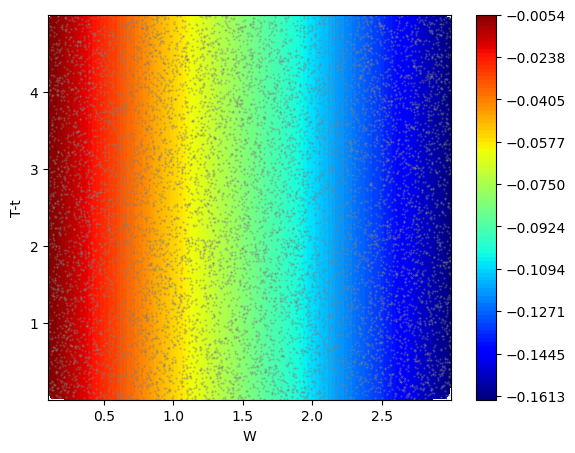

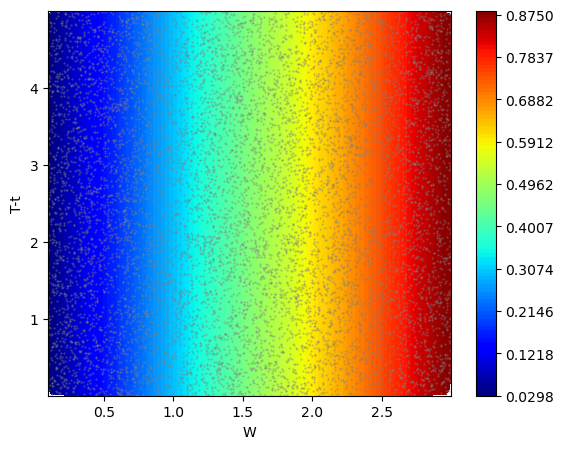

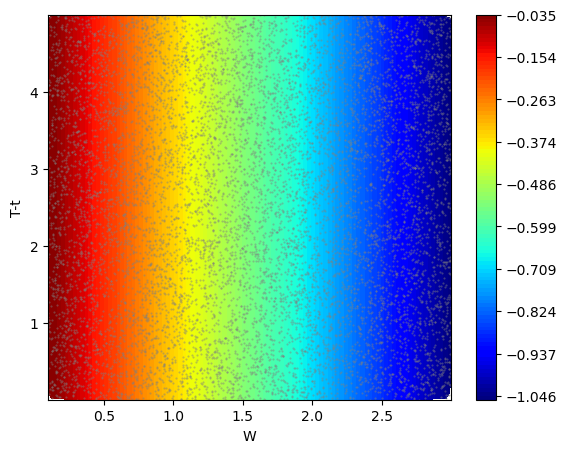

****************************************************************************************************


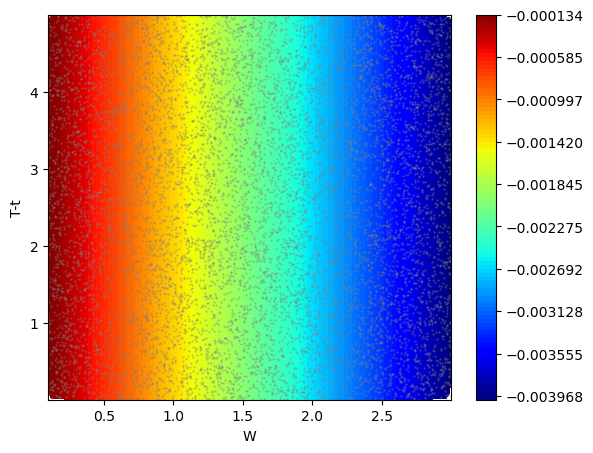

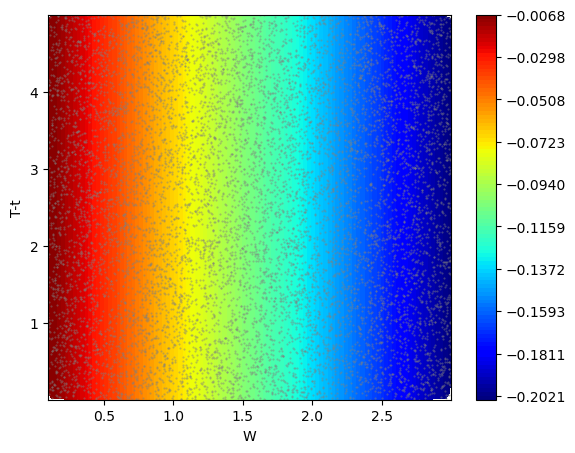

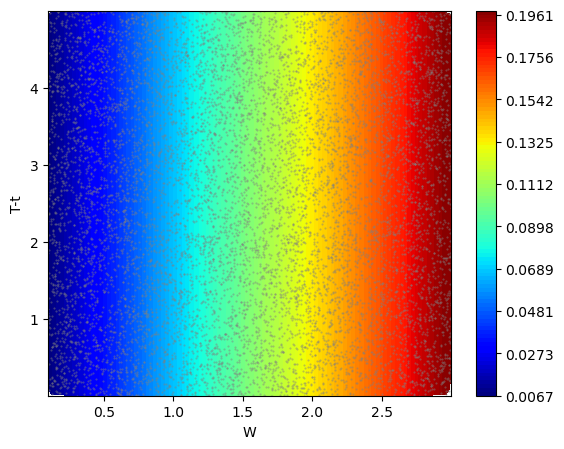

****************************************************************************************************
err_m_a: 1.182354e+00  err_m_b: 9.803700e-01  err_m_0_a: -1.182354e+00  err_m_0_b: -9.803698e-01  err_m_1_a: -1.182354e+00  err_m_1_b: -9.803698e-01 U: 0.000000e+00  lr_m:  1.000e-03


In [10]:
lr_m = opt_m.param_groups[0]['lr']
plot(False,0,0,-1,lr_m)

min: 60


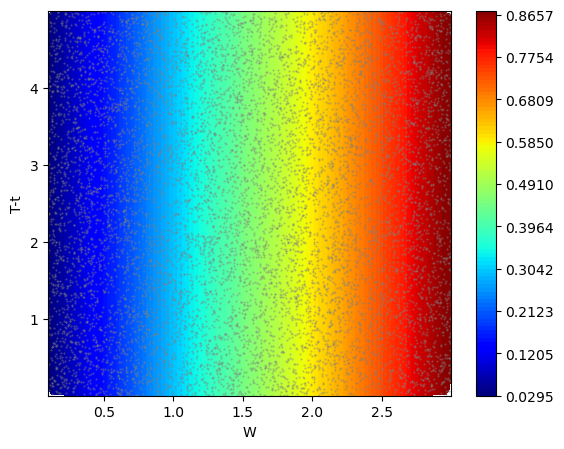

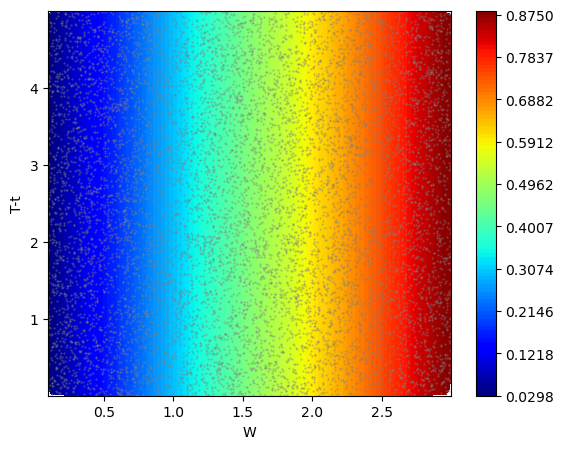

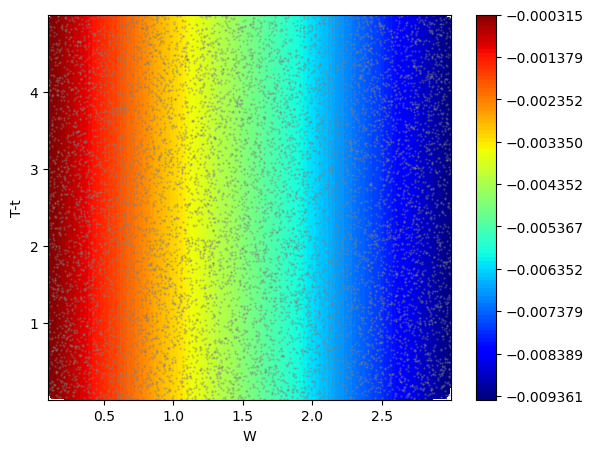

****************************************************************************************************


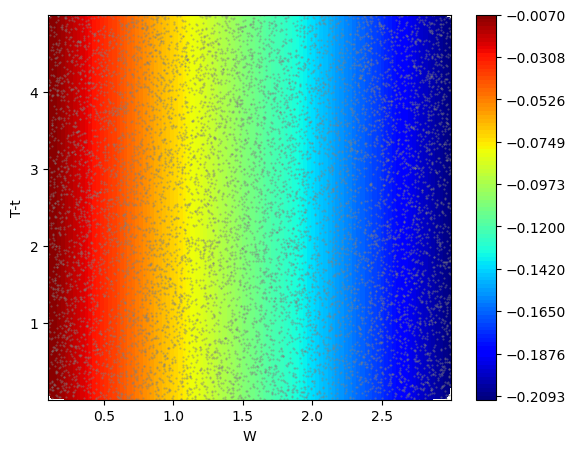

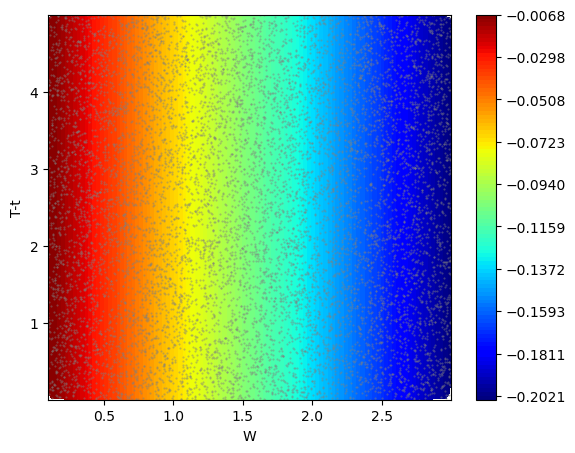

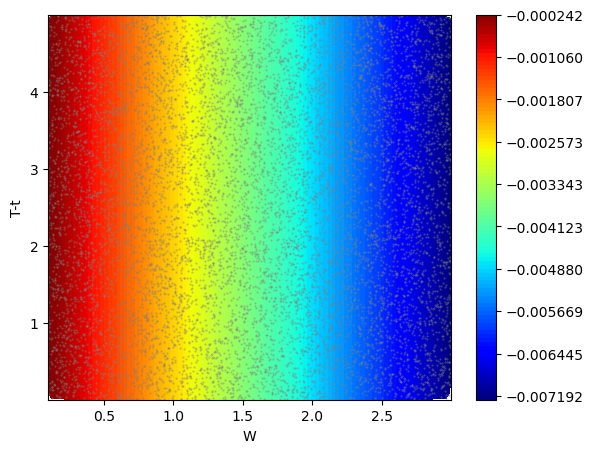

****************************************************************************************************
err_m_a: 1.058634e-02  err_m_b: 3.558152e-02  err_m_0_a: -1.058644e-02  err_m_0_b: 3.558152e-02  err_m_1_a: -1.058639e-02  err_m_1_b: 3.558157e-02 U: 7.949569e-01  lr_m:  1.000e-03
20424 60.0 ****************************************************************************************************
finished


In [11]:
for min in [1,5,10,30,60] :

    torch.manual_seed(seed)
    np.random.seed(seed)
    
    net_m = MyopicNet()
    net_m = net_m.to(dev)
    
    opt_m = torch.optim.Adam(net_m.parameters(),lr=1e-3)
    
    set_time = 60*min
    
    flag = False
    flag_draw = False
    i = 0
    start_time = time.time()
    start_time_draw = time.time()
    while True :
    
       # ************************************************************************************************** #
    
        opt_m.zero_grad()
    
        T,W,dt = generate_domain(n)
    
        for k in range(m) :
            t = k*dt
    
            state = torch.vstack([W,T-t]).T
            pi = net_m(state).view(1,-1) * torch.ones_like(W).view(-1,1)
            
            dZ = torch.randn([n,2],device=dev)*torch.sqrt(dt).view(-1,1)
            dZ[:,1] = corr*dZ[:,0] + np.sqrt(1-corr**2)*dZ[:,1]
            vol_total = torch.sqrt( (vol[0]*pi[:,0])**2 + (vol[1]*pi[:,1])**2 + 2*corr*vol[0]*vol[1]*pi[:,0]*pi[:,1] )
            W = W*torch.exp( (mu[0]*pi[:,0] + mu[1]*pi[:,1] + r*(1-pi[:,0]-pi[:,1]) - 0.5*vol_total**2) *dt + vol[0]*pi[:,0]*dZ[:,0] + vol[1]*pi[:,1]*dZ[:,1] )
            W = torch.relu(W - lb) + lb
    
        t = T
        U = W**(1-gamma)/(1-gamma)     
        U = -U.nanmean()
        U.backward()
       
        max_norm = 0.01
        torch.nn.utils.clip_grad_norm_(net_m.parameters(), max_norm)
    
        opt_m.step()    
    
        # ************************************************************************************************** #
    
        elapsed_time = time.time() - start_time
        if elapsed_time > set_time : 
            flag = True
    
        elapsed_time_draw = time.time() - start_time_draw
        if elapsed_time_draw > 60 : 
            start_time_draw = time.time()
            flag_draw = True
        
        if flag_draw or i == 0 or flag :
            clear_output(wait=True)
            lr_m = opt_m.param_groups[0]['lr']
            print('min:',min)
            plot(False,U,0,i,lr_m)
            print(i,elapsed_time//60,'*'*100)
            flag_draw = False
        if flag :
            plot(True,U,0,i,lr_m)
    
        if flag : break
        i = i+1    
    
    print('finished')